# Model Evaluation

#### Load the model

In [2]:
import joblib
import pandas as pd

random_forest = joblib.load("../models/random_forest.pkl")
xgboost = joblib.load("../models/xgboost.pkl")

x_train = pd.read_csv("../data/processed/train/x_train.csv")
x_test = pd.read_csv("../data/processed/test/x_test.csv")
y_test = pd.read_csv("../data/processed/test/y_test.csv")

#### Predict on test set

In [5]:
# rf_pred = random_forest.predict(x_test)
xgboost_pred = xgboost.predict(x_test)

#### Evaluation begins

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# XGBoost evaluation metrics
print("Accuracy :", accuracy_score(y_test, xgboost_pred))
print("Precision:", precision_score(y_test, xgboost_pred, average="weighted"))
print("Recall   :", recall_score(y_test, xgboost_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, xgboost_pred, average="weighted"))

# Random Forest evaluation metrics
# print("Accuracy :", accuracy_score(y_test, rf_pred))
# print("Precision:", precision_score(y_test, rf_pred, average="weighted"))
# print("Recall   :", recall_score(y_test, rf_pred, average="weighted"))
# print("F1 Score :", f1_score(y_test, rf_pred, average="weighted"))

Accuracy : 0.8374384236453202
Precision: 0.8435713378177739
Recall   : 0.8374384236453202
F1 Score : 0.8372377276362348


#### Classification Report

In [24]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84        81
           1       0.78      0.90      0.83        67
           2       0.88      0.91      0.89        55

    accuracy                           0.85       203
   macro avg       0.86      0.86      0.86       203
weighted avg       0.86      0.85      0.85       203



#### Confusion Matrix

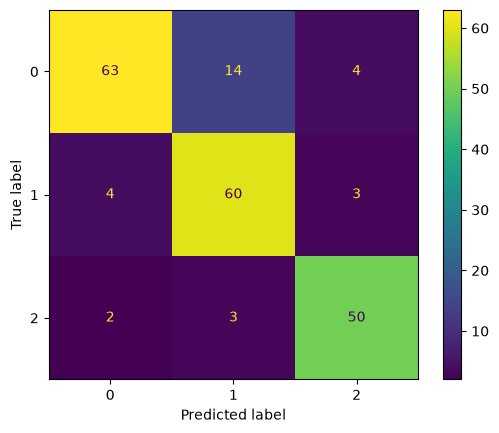

In [25]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

#### Feature Importance

In [26]:
import pandas as pd

# rf_importance = pd.DataFrame({
#     "Feature": x_train.columns,
#     "Importance": random_forest.feature_importances_
# })

xgb_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": xgboost.feature_importances_
})

# rf_importance.sort_values("Importance", ascending=False)
xgb_importance.sort_values("Importance", ascending=False)

,Feature,Importance
1,SystolicBP,0.275216
3,BS,0.255898
4,BodyTemp,0.166500
0,Age,0.103736
2,DiastolicBP,0.102023
5,HeartRate,0.096628
